## Conexión con GitHub

In [ ]:
import shutil
shutil.rmtree('C:/Users/anton/Downloads/.git', ignore_errors=True)
print("Repositorio eliminado de Descargas.")

In [1]:
!git init
!git add .
!git commit -m "Commit inicial"
!git branch -M main
!git remote add origin https://github.com/antonmrtnz/lab2026.git
!git push -u origin main

Initialized empty Git repository in C:/Users/anton/Downloads/lab2026Final/.git/


hint: Using 'master' as the name for the initial branch. This default branch name
hint: will change to "main" in Git 3.0. To configure the initial branch name
hint: to use in all of your new repositories, which will suppress this warning,
hint: call:
hint:
hint: 	git config --global init.defaultBranch <name>
hint:
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint:
hint: 	git branch -m <name>
hint:
hint: Disable this message with "git config set advice.defaultBranchName false"


[master (root-commit) 0fdc15d] Commit inicial
 2 files changed, 1932 insertions(+)
 create mode 100644 .ipynb_checkpoints/FINAL-checkpoint.ipynb
 create mode 100644 FINAL.ipynb


To https://github.com/antonmrtnz/lab2026.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/antonmrtnz/lab2026.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [2]:
!git push -u origin main --force

branch 'main' set up to track 'origin/main'.


To https://github.com/antonmrtnz/lab2026.git
 + b419875...0fdc15d main -> main (forced update)


In [29]:
# =============================================================
# Imports — Lab Astronomía 2026 · S2
# =============================================================
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy import units as u
from astropy.visualization import ZScaleInterval, ImageNormalize, SqrtStretch
from astropy.stats import sigma_clipped_stats

from ccdproc import CCDData, Combiner, subtract_bias, subtract_dark

# Directorios del curso
CALIB_DIR = Path("calib_data")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

print("✅ Imports OK")
import astropy, ccdproc
print(f"   astropy  {astropy.__version__}")
print(f"   ccdproc  {ccdproc.__version__}")

✅ Imports OK
   astropy  8.0.1
   ccdproc  2.5.1


## BIAS

In [30]:
#Vamos a ver el procedimiento completo para llegar a la imagen calibrada, verificamos los BIAS
import glob 
import os
from astropy.io import fits

#Carpeta de búsqueda
path_bias = r"C:\Users\anton\Downloads\lab2026Final\data\ccd\bias" 

# Construcción correcta de la ruta para Windows
ruta_busqueda = os.path.join(path_bias, "*.fits")
archivo_bias = sorted(glob.glob(ruta_busqueda))

datos_bias = []
headers_bias = []

#Iterando
for archivo in archivo_bias:
    with fits.open(archivo) as hdul:
        # hdul.info() # Sugiero dejar esto comentado para no inundar la pantalla de texto redundante
        header = hdul[0].header.copy()     # copia del header
        data   = hdul[0].data.copy()       # copia de los datos como numpy array
        
        # Guardamos los datos en las listas 
        datos_bias.append(data)
        headers_bias.append(header)
        
        # Extraemos solo el nombre del archivo para una impresión más limpia
        nombre_limpio = os.path.basename(archivo)
        print(f"Leído: {nombre_limpio}")
        
print()
print(f"Archivos de bias encontrados y guardados en memoria: {len(datos_bias)}")

Leído: ccd.001.0.fits
Leído: ccd.002.0.fits
Leído: ccd.003.0.fits
Leído: ccd.004.0.fits
Leído: ccd.005.0.fits
Leído: ccd.006.0.fits
Leído: master_bias.fits

Archivos de bias encontrados y guardados en memoria: 7


## Opening a BIAS file 

=== Header del bias ===
  IMAGETYP     BIAS
  EXPTIME      0.0
  GAIN         1.1
  RDNOISE      — no disponible —
  NAXIS1       2080
  NAXIS2       4128

=== Array ===
  Forma   : (4128, 2080)
  Media   : 1144.55 ADU
  Mediana : 1137.00 ADU
  Std     : 43.30 ADU
  Mín/Máx : 353 / 65535 ADU


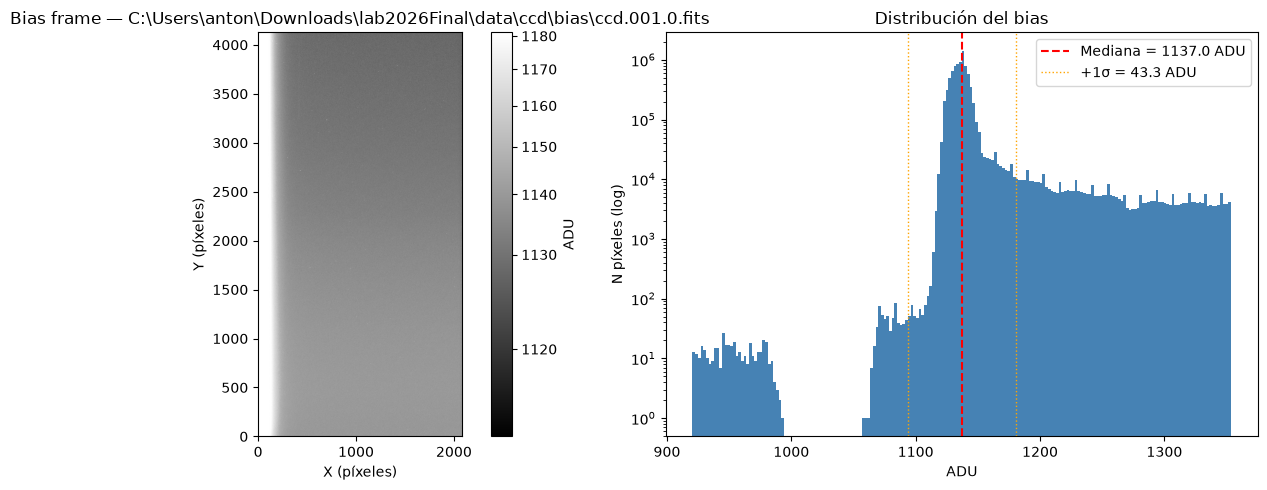

In [31]:
# Abrir un bias de ejemplo e inspeccionar
bias_ejemplo = CCDData.read(archivo_bias[0], unit="adu")

print("=== Header del bias ===")
for kw in ["IMAGETYP", "EXPTIME", "GAIN", "RDNOISE", "NAXIS1", "NAXIS2"]:
    print(f"  {kw:<12} {bias_ejemplo.header.get(kw, '— no disponible —')}")

print(f"\n=== Array ===")
print(f"  Forma   : {bias_ejemplo.data.shape}")
print(f"  Media   : {bias_ejemplo.data.mean():.2f} ADU")
print(f"  Mediana : {np.median(bias_ejemplo.data):.2f} ADU")
print(f"  Std     : {bias_ejemplo.data.std():.2f} ADU")
print(f"  Mín/Máx : {bias_ejemplo.data.min():.0f} / {bias_ejemplo.data.max():.0f} ADU")


# Visualización del bias: imagen + histograma
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Imagen ---
norm = ImageNormalize(bias_ejemplo.data, interval=ZScaleInterval(), stretch=SqrtStretch())
im = axes[0].imshow(bias_ejemplo.data, norm=norm, cmap="gray", origin="lower")
plt.colorbar(im, ax=axes[0], label="ADU")
axes[0].set_title(f"Bias frame — {archivo_bias[0]}")
axes[0].set_xlabel("X (píxeles)")
axes[0].set_ylabel("Y (píxeles)")

# --- Histograma ---
med = np.median(bias_ejemplo.data)
std = bias_ejemplo.data.std()
axes[1].hist(bias_ejemplo.data.flatten(), bins=200,
             range=(med - 5*std, med + 5*std),
             color="steelblue", edgecolor="none", log=True)
axes[1].axvline(med, color="red",    lw=1.5, ls="--", label=f"Mediana = {med:.1f} ADU")
axes[1].axvline(med + std, color="orange", lw=1, ls=":", label=f"+1σ = {std:.1f} ADU")
axes[1].axvline(med - std, color="orange", lw=1, ls=":")
axes[1].set_xlabel("ADU")
axes[1].set_ylabel("N píxeles (log)")
axes[1].set_title("Distribución del bias")
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "S2_bias_ejemplo.png", dpi=150, bbox_inches="tight")
plt.show()


## Master BIAS creation

In [32]:
# Cargar todos los bias frames en una lista de CCDData
bias_list = []
for f in archivo_bias:
    ccd = CCDData.read(f, unit="adu")
    bias_list.append(ccd)
    print(f"  Cargado: {f.split('/')[-1]}  |  mediana = {np.median(ccd.data):.1f} ADU")

print(f"\nTotal de bias frames cargados: {len(bias_list)}")

  Cargado: C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\ccd.001.0.fits  |  mediana = 1137.0 ADU
  Cargado: C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\ccd.002.0.fits  |  mediana = 1126.0 ADU
  Cargado: C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\ccd.003.0.fits  |  mediana = 1123.0 ADU
  Cargado: C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\ccd.004.0.fits  |  mediana = 1122.0 ADU
  Cargado: C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\ccd.005.0.fits  |  mediana = 1121.0 ADU
  Cargado: C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\ccd.006.0.fits  |  mediana = 1121.0 ADU
  Cargado: C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\master_bias.fits  |  mediana = 1123.5 ADU

Total de bias frames cargados: 7


## Combinación Sigma Clipping y Visualización Master BIAS

Master Bias construido:
  Frames combinados : 7
  Mediana           : 1123.50 ADU
  Std               : 42.05 ADU
  Guardado en       : C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\master_bias_1.fits


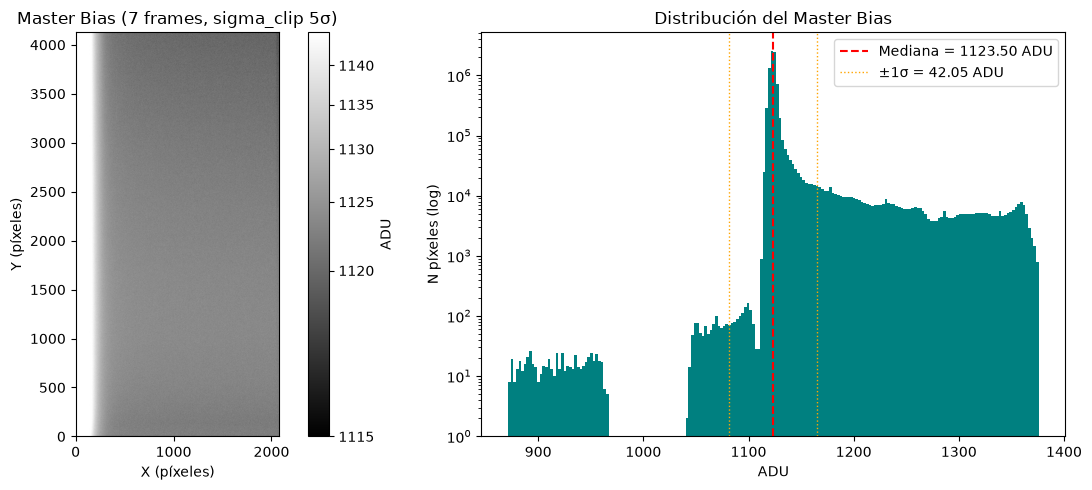

In [34]:
# Crear el combinador y aplicar sigma clipping
combiner_bias = Combiner(bias_list)

# Sigma clipping: rechaza píxeles a más de 5σ de la mediana (conservador)
combiner_bias.sigma_clipping(low_thresh=5, high_thresh=5)

# Combinación por mediana
master_bias = combiner_bias.median_combine()
master_bias.header["IMAGETYP"] = "MASTER_BIAS"
master_bias.header["NCOMBINE"] = len(bias_list)
master_bias.header["PIPELINE"] = "Lab2026v1"

# Guardar
ruta_guardado = r"C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\master_bias_1.fits"
master_bias.write(ruta_guardado, overwrite=True)

print("Master Bias construido:")
print(f"  Frames combinados : {len(bias_list)}")
print(f"  Mediana           : {np.median(master_bias.data):.2f} ADU")
print(f"  Std               : {master_bias.data.std():.2f} ADU")
print(f"  Guardado en       : {ruta_guardado}")

# Visualización del Master Bias
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Imagen
norm = ImageNormalize(master_bias.data, interval=ZScaleInterval(), stretch=SqrtStretch())
im = axes[0].imshow(master_bias.data, norm=norm, cmap="gray", origin="lower")
plt.colorbar(im, ax=axes[0], label="ADU")
axes[0].set_title(f"Master Bias ({len(bias_list)} frames, sigma_clip 5σ)")
axes[0].set_xlabel("X (píxeles)")
axes[0].set_ylabel("Y (píxeles)")

# Histograma
med = np.median(master_bias.data)
std = master_bias.data.std()
axes[1].hist(master_bias.data.flatten(), bins=200,
             range=(med - 6*std, med + 6*std),
             color="teal", edgecolor="none", log=True)
axes[1].axvline(med, color="red",    lw=1.5, ls="--", label=f"Mediana = {med:.2f} ADU")
axes[1].axvline(med + std, color="orange", lw=1, ls=":", label=f"±1σ = {std:.2f} ADU")
axes[1].axvline(med - std, color="orange", lw=1, ls=":")
axes[1].set_xlabel("ADU")
axes[1].set_ylabel("N píxeles (log)")
axes[1].set_title("Distribución del Master Bias")
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "S2_master_bias.png", dpi=150, bbox_inches="tight")
plt.show()

## LECTURA ARCHIVOS DARK

In [35]:
# Cargar darks y restar bias a cada uno
# Listar archivos de dark
path_bias = r"C:\Users\anton\Downloads\lab2026Final\data\ccd\bias"
path_dark = r"C:\Users\anton\Downloads\lab2026Final\data\ccd\dark"

root_dark = os.path.join(path_dark,"*.fits")
dark_files = sorted(glob.glob(root_dark))
print(f"Archivos de dark encontrados: {len(dark_files)}")
for f in dark_files:
    print(f"  {f.split('/')[-1]}")

datos_dark = []
headers_dark = []
dark_bias_sub = []

# Iterando una sola vez para extraer datos y restar el bias
for archivo in dark_files:
    nombre_limpio = os.path.basename(archivo)
    
    # 1. Leer con CCDData
    d = CCDData.read(archivo, unit="adu")
    
    # Guardamos raw (si es que los necesitas para otra cosa)
    datos_dark.append(d.data.copy())
    headers_dark.append(d.header.copy())
    
    # 2. Restar bias
    d_sub = subtract_bias(d, master_bias)
    
    # 3. Truncar negativos en la imagen RESTADA
    d_sub.data[d_sub.data < 0] = 0.0
    
    dark_bias_sub.append(d_sub)
    
    # Extracción de metadatos y cálculo de mediana apuntando a .data
    t = d.header.get("EXPTIME", "?")
    mediana = np.median(d_sub.data)
    
    print(f"Leído: {nombre_limpio:<15} | EXPTIME={t}s | mediana (post-bias) = {mediana:.2f} ADU")

print(f"\nTotal de dark frames (bias-subtracted) listos: {len(dark_bias_sub)}")

Archivos de dark encontrados: 5
  C:\Users\anton\Downloads\lab2026Final\data\ccd\dark\ccd.013.0.fits
  C:\Users\anton\Downloads\lab2026Final\data\ccd\dark\ccd.014.0.fits
  C:\Users\anton\Downloads\lab2026Final\data\ccd\dark\ccd.015.0.fits
  C:\Users\anton\Downloads\lab2026Final\data\ccd\dark\master_dark.fits
  C:\Users\anton\Downloads\lab2026Final\data\ccd\dark\master_dark_ccd.fits
Leído: ccd.013.0.fits  | EXPTIME=300.0s | mediana (post-bias) = 69.00 ADU
Leído: ccd.014.0.fits  | EXPTIME=300.0s | mediana (post-bias) = 69.00 ADU
Leído: ccd.015.0.fits  | EXPTIME=300.0s | mediana (post-bias) = 68.50 ADU
Leído: master_dark.fits | EXPTIME=300.0s | mediana (post-bias) = 0.00 ADU
Leído: master_dark_ccd.fits | EXPTIME=300.0s | mediana (post-bias) = 0.00 ADU

Total de dark frames (bias-subtracted) listos: 5


## Cargar Darks y restar el MASTER BIAS

In [37]:
from astropy.nddata import CCDData
from ccdproc import subtract_bias

#Ruta master bias (root) #Editar esto después
root_masterbias = r"C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\master_bias_1.fits"
master_bias = CCDData.read(root_masterbias, unit="adu")

dark_bias_sub = []

for f in dark_files:
    d = CCDData.read(f, unit="adu")
    d_sub = subtract_bias(d, master_bias)
    
    # 2. Truncar los píxeles negativos en la imagen restada
    d_sub.data[d_sub.data < 0] = 0.0
    
    dark_bias_sub.append(d_sub)
    
    t = d_sub.header.get("EXPTIME", "?")
    nombre_limpio = os.path.basename(f)
    
    # 3. Calcular la mediana apuntando estrictamente a .data
    print(f"  {nombre_limpio:<15} |  EXPTIME={t}s  |  mediana (post-bias) = {np.median(d_sub.data):.2f} ADU")

print(f"\nTotal de dark frames (bias-subtracted): {len(dark_bias_sub)}")

  ccd.013.0.fits  |  EXPTIME=300.0s  |  mediana (post-bias) = 69.00 ADU
  ccd.014.0.fits  |  EXPTIME=300.0s  |  mediana (post-bias) = 69.00 ADU
  ccd.015.0.fits  |  EXPTIME=300.0s  |  mediana (post-bias) = 68.50 ADU
  master_dark.fits |  EXPTIME=300.0s  |  mediana (post-bias) = 0.00 ADU
  master_dark_ccd.fits |  EXPTIME=300.0s  |  mediana (post-bias) = 0.00 ADU

Total de dark frames (bias-subtracted): 5


In [39]:
from astropy.io import fits
from ccdproc import Combiner

# Combinar darks con sigma clipping
print("Iniciando combinación de Darks con sigma clipping...")
combiner_dark = Combiner(dark_bias_sub)
combiner_dark.sigma_clipping(low_thresh=5, high_thresh=5)
master_dark = combiner_dark.median_combine()

# Metadata
t_dark_exp = dark_files[0]  # para recuperar EXPTIME del primer dark
with fits.open(t_dark_exp) as hdul:
    t_exp_dark = hdul[0].header.get("EXPTIME", 300.0)

# Asignación de cabeceras (usamos .meta, que es el estándar seguro para CCDData)
master_dark.meta["IMAGETYP"] = "MASTER_DARK"
master_dark.meta["NCOMBINE"] = len(dark_bias_sub)
master_dark.meta["EXPTIME"]  = t_exp_dark
master_dark.meta["BIASSUB"]  = (True, "Bias restado antes de combinar")
master_dark.meta["PIPELINE"] = "Lab2026v1"

# Guardar con la ruta absoluta de Windows
directorio_dark = r"C:\Users\anton\Downloads\lab2026Final\data\ccd\dark"
ruta_guardado = os.path.join(directorio_dark, "master_dark_1.fits")

# Sobrescribir si ya existe
master_dark.write(ruta_guardado, overwrite=True)

print("Master Dark construido:")
print(f"  Frames combinados : {len(dark_bias_sub)}")
print(f"  EXPTIME           : {t_exp_dark:.0f} s")
print(f"  Mediana           : {np.median(master_dark.data):.4f} ADU")
print(f"  Std               : {master_dark.data.std():.4f} ADU")
print(f"  Guardado en       : {ruta_guardado}")

Iniciando combinación de Darks con sigma clipping...
Master Dark construido:
  Frames combinados : 5
  EXPTIME           : 300 s
  Mediana           : 65.0000 ADU
  Std               : 134.0951 ADU
  Guardado en       : C:\Users\anton\Downloads\lab2026Final\data\ccd\dark\master_dark_1.fits


## Sigma Clipping

C:\Users\anton\AppData\Local\Temp\ipykernel_16428\401427150.py:31: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\anton\AppData\Local\Temp\ipykernel_16428\401427150.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(PLOTS_DIR / "S2_sigma_clipping_demo.png", dpi=150, bbox_inches="tight")
C:\Users\anton\anaconda3\envs\astro_Env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


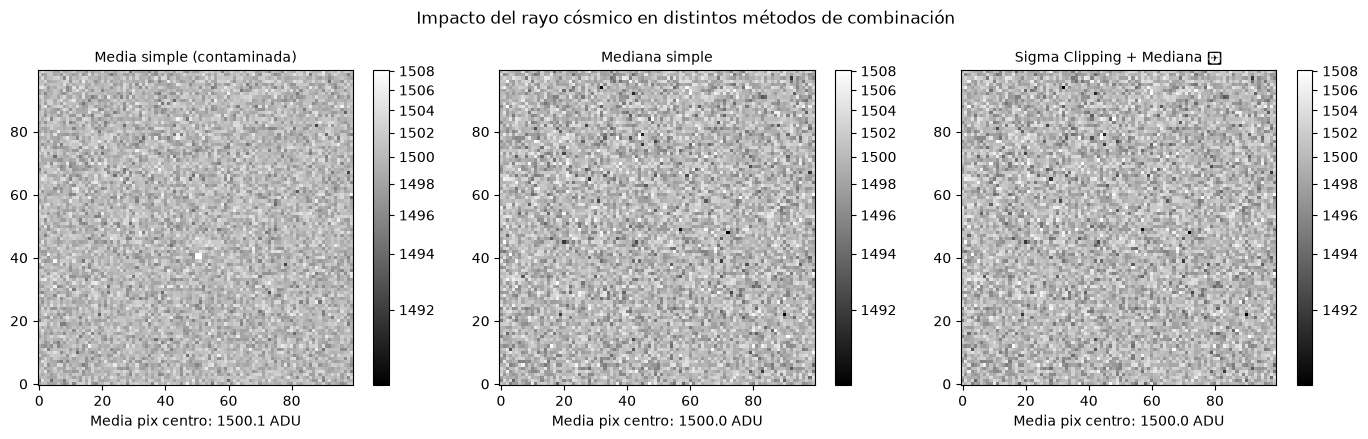

Zona del rayo cósmico — Media: 5402 ADU  |  Mediana SC: 1501.3 ADU


In [40]:
# Demostración sintética: impacto de un outlier en promedio vs mediana
rng = np.random.default_rng(42)

# Simular 15 bias frames con valor ~1500 ADU
n_frames = 15
shape = (100, 100)
frames = [rng.normal(1500, 8, shape) for _ in range(n_frames)]

# Inyectar un rayo cósmico en el frame 7
frames[7][40:42, 50:52] = 60000  # saturado

stack = np.array(frames)

# Combinaciones
mean_comb   = stack.mean(axis=0)
median_comb = np.median(stack, axis=0)
_, median_sc, _ = sigma_clipped_stats(stack, sigma=5, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
norm_ref = ImageNormalize(median_comb, interval=ZScaleInterval(), stretch=SqrtStretch())

for ax, img, titulo in zip(axes,
    [mean_comb, median_comb, median_sc],
    ["Media simple (contaminada)", "Mediana simple", "Sigma Clipping + Mediana ✅"]):
    im = ax.imshow(img, norm=norm_ref, cmap="gray", origin="lower")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel(f"Media pix centro: {img[45:55,45:55].mean():.1f} ADU")
    plt.colorbar(im, ax=ax)

plt.suptitle("Impacto del rayo cósmico en distintos métodos de combinación", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "S2_sigma_clipping_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Zona del rayo cósmico — Media: {mean_comb[40,50]:.0f} ADU  |  Mediana SC: {median_sc[40,50]:.1f} ADU")

## COMPARACIÓN MASTER BIAS VS MASTER DARK

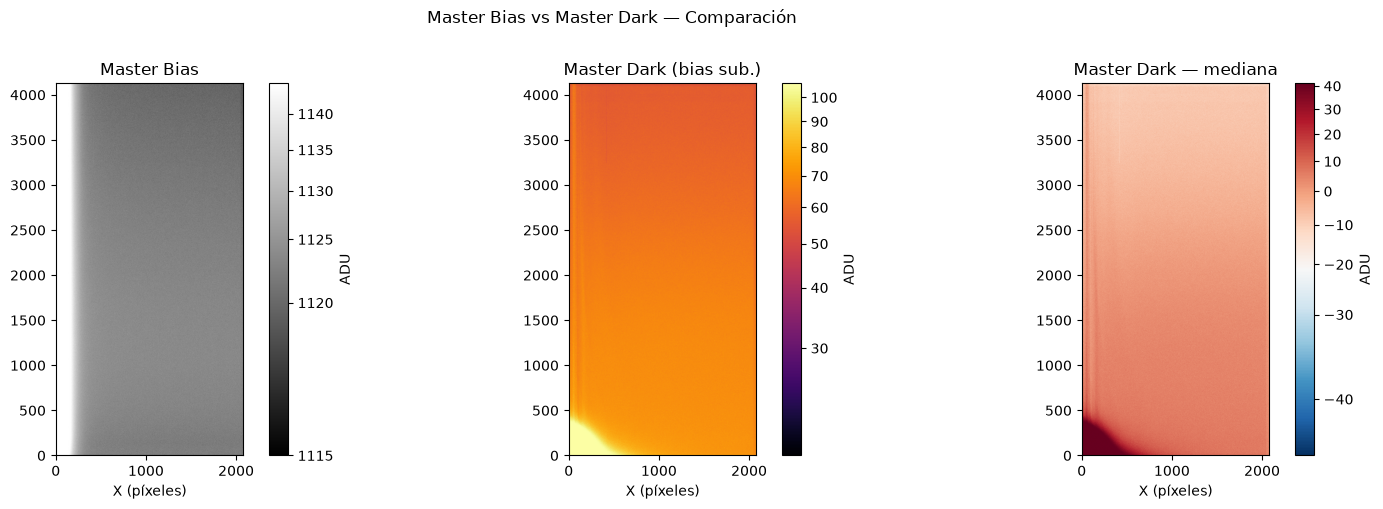

In [41]:
# Comparación visual Master Bias vs Master Dark
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

imgs   = [master_bias.data, master_dark.data,
          master_dark.data - np.median(master_dark.data)]
titulos = ["Master Bias", "Master Dark (bias sub.)", "Master Dark — mediana"]
cmaps  = ["gray", "inferno", "RdBu_r"]

for ax, img, titulo, cmap in zip(axes, imgs, titulos, cmaps):
    norm = ImageNormalize(img, interval=ZScaleInterval(), stretch=SqrtStretch())
    im = ax.imshow(img, norm=norm, cmap=cmap, origin="lower")
    plt.colorbar(im, ax=ax, label="ADU")
    ax.set_title(titulo)
    ax.set_xlabel("X (píxeles)")

plt.suptitle("Master Bias vs Master Dark — Comparación", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "S2_bias_vs_dark.png", dpi=150, bbox_inches="tight")
plt.show()

## Flats

In [53]:
import os
import glob
import numpy as np
from astropy.io import fits

# 1. Definir rutas absolutas
path_flat = r"C:\Users\anton\Downloads\lab2026Final\data\ccd\flat\salva"
ruta_flats = os.path.join(path_flat, "*.fits")
archivos_flat = sorted(glob.glob(ruta_flats))

root_masterbias = r"C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\master_bias_1.fits"
master_bias = fits.getdata(root_masterbias).astype(np.float32)

flats_calibrados = []

print("Iniciando reconstrucción blindada del Master Flat...\n")

for f in archivos_flat:
    # Cargar forzando formato decimal para evitar errores de tipo uint16
    datos_flat = fits.getdata(f).astype(np.float32)
    
    # Restar Master Bias y truncar negativos de forma segura
    flat_sin_bias = datos_flat - master_bias
    flat_sin_bias[flat_sin_bias < 0.0] = 0.0
    
    # Normalización por la mediana con seguro contra división por cero
    mediana_flat = np.nanmedian(flat_sin_bias)
    
    if mediana_flat <= 0.0:
        print(f"⚠️ PELIGRO: Mediana nula en {os.path.basename(f)}. Usando 1.0 como salvavidas.")
        mediana_flat = 1.0
        
    flat_normalizado = flat_sin_bias / mediana_flat
    flats_calibrados.append(flat_normalizado)
    
    print(f"Procesado: {os.path.basename(f):<15} | Mediana post-bias: {mediana_flat:.2f} ADU")

# Apilar y combinar
cubo_flats = np.array(flats_calibrados)
master_flat_data = np.nanmedian(cubo_flats, axis=0)

# Extracción y limpieza del header
with fits.open(archivos_flat[0]) as hdul:
    hdul.verify('silentfix')
    header_flat = hdul[0].header.copy()

for key in ['COMMENT', 'HISTORY', '']:
    if key in header_flat: del header_flat[key]

for key in list(header_flat.keys()):
    val = header_flat[key]
    if isinstance(val, str) and '\x00' in val: del header_flat[key]
    elif '\x00' in str(val): del header_flat[key]

header_flat['IMAGETYP'] = 'MASTER_FLAT'
header_flat['HISTORY'] = 'Master Flat (Blindado): Bias restado, floats32, normalizado'

# Guardado
ruta_guardado = os.path.join(path_flat, "master_flat_1.fits")
fits.PrimaryHDU(master_flat_data, header=header_flat).writeto(ruta_guardado, overwrite=True, output_verify="silentfix")

print(f"\n✅ Master Flat reconstruido sin NaNs y guardado en:\n{ruta_guardado}")
print(f"   Mínimo final : {np.nanmin(master_flat_data):.2f}")
print(f"   Máximo final : {np.nanmax(master_flat_data):.2f}")
print(f"   NaNs totales : {np.isnan(master_flat_data).sum()}")

Iniciando reconstrucción blindada del Master Flat...

Procesado: ccd.014.0.fits  | Mediana post-bias: 20182.00 ADU
Procesado: ccd.015.0.fits  | Mediana post-bias: 20178.50 ADU
Procesado: ccd.016.0.fits  | Mediana post-bias: 20167.00 ADU

✅ Master Flat reconstruido sin NaNs y guardado en:
C:\Users\anton\Downloads\lab2026Final\data\ccd\flat\salva\master_flat_1.fits
   Mínimo final : 0.00
   Máximo final : 2.67
   NaNs totales : 0


## Construcción Light

In [55]:
## Podemos verificar los archivos MASTER en busca de NaNs
import numpy as np
from astropy.io import fits

mb = fits.getdata(r"C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\master_bias_1.fits")
md = fits.getdata(r"C:\Users\anton\Downloads\lab2026Final\data\ccd\dark\master_dark_1.fits")
mf = fits.getdata(r"C:\Users\anton\Downloads\lab2026Final\data\ccd\flat\salva\master_flat_1.fits")

print("--- Diagnóstico de NaNs en Maestros ---")
print(f"Master Bias : {np.isnan(mb).sum():>8} NaNs | Min: {np.nanmin(mb):.2f} | Max: {np.nanmax(mb):.2f}")
print(f"Master Dark : {np.isnan(md).sum():>8} NaNs | Min: {np.nanmin(md):.2f} | Max: {np.nanmax(md):.2f}")
print(f"Master Flat : {np.isnan(mf).sum():>8} NaNs | Min: {np.nanmin(mf):.2f} | Max: {np.nanmax(mf):.2f}")

--- Diagnóstico de NaNs en Maestros ---
Master Bias :        0 NaNs | Min: 351.50 | Max: 65535.00
Master Dark :        0 NaNs | Min: 0.00 | Max: 8963.50
Master Flat :        0 NaNs | Min: 0.00 | Max: 2.67


Archivos Light a calibrar: 1

✅ Listo: ccd.037.0_calib.fits calibrado exitosamente.

Iniciando módulo de visualización y diagnóstico vital...
Estadísticas de la imagen calibrada (ccd.037.0_calib.fits):
  Mínimo          : 0.00 ADU
  Máximo          : 3320832.70 ADU
  Promedio        : 694.64 ADU
  NaNs detectados : 0 píxeles


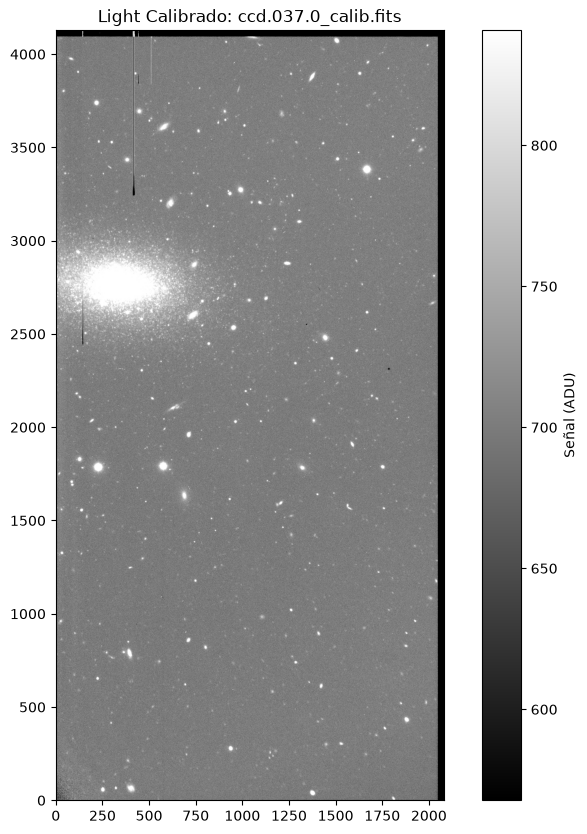


Proceso de calibración finalizado.


In [57]:
import os
import glob
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval

# Cargar los archivos maestros con las rutas absolutas nuevas
master_bias = fits.getdata(r"C:\Users\anton\Downloads\lab2026Final\data\ccd\bias\master_bias_1.fits")
master_dark = fits.getdata(r"C:\Users\anton\Downloads\lab2026Final\data\ccd\dark\master_dark_1.fits")
master_flat = fits.getdata(r"C:\Users\anton\Downloads\lab2026Final\data\ccd\flat\salva\master_flat_1.fits")

# Preparar el directorio de Lights
root_lights = r"C:\Users\anton\Downloads\lab2026Final\data\ccd\light"
path_lights = os.path.join(root_lights, "*.fits")
archivos_light = sorted(glob.glob(path_lights))

# Carpeta para guardar los resultados (subcarpeta para mantener el orden)
out_folder = os.path.join(root_lights, "calibradas")
os.makedirs(out_folder, exist_ok=True)

print(f"Archivos Light a calibrar: {len(archivos_light)}\n")

if len(archivos_light) == 0:
    print("No se encontraron imágenes de ciencia. Verifica tu directorio.")
else:
    # Procesar cada imagen
    for f in archivos_light:
        with fits.open(f) as hdul:
            hdul.verify('silentfix')
            header = hdul[0].header.copy()
            # Convertir a float32 para la división decimal
            data_light = hdul[0].data.astype(np.float32)

        # Procedimiento de calibración 
        # Recordar: [(Light - Bias)- Dark]/Flat
        
        # A) Restar el Bias
        data_calib = data_light - master_bias
        
        # B) Restar el Dark
        data_calib = data_calib - master_dark
        
        # Prevenir píxeles imposibles (ruido bajo cero)
        data_calib[data_calib < 0] = 0.0
        
        # C) Dividir por el Flat (protegiendo contra división por cero)
        flat_seguro = np.where(master_flat == 0, 1.0, master_flat)
        data_calib = data_calib / flat_seguro

        # Limpieza de Headers 
        if 'COMMENT' in header: del header['COMMENT']
        if 'HISTORY' in header: del header['HISTORY']
        if '' in header: del header['']

        for key in list(header.keys()):
            valor = header[key]
            if isinstance(valor, str) and '\x00' in valor:
                del header[key]
            elif '\x00' in str(valor):
                del header[key]

        # GUARDADO
        header['IMAGETYP'] = 'CALIBRATED_LIGHT'
        header['HISTORY'] = 'Calibrado: Bias restado, Dark restado, dividido por Master Flat'
        
        # Manejo de rutas Windows y agregado del sufijo _calib
        nombre_limpio = os.path.basename(f)
        nombre_archivo = nombre_limpio.replace('.fits', '_calib.fits')
        ruta_guardado = os.path.join(carpeta_salida, nombre_archivo)
        
        fits.PrimaryHDU(data_calib, header=header).writeto(ruta_guardado, overwrite=True, output_verify="silentfix")
        
        print(f"✅ Listo: {nombre_archivo} calibrado exitosamente.")
        
    print("\nIniciando módulo de visualización y diagnóstico vital...")

    # Radiografía de los datos resultantes
    print(f"Estadísticas de la imagen calibrada ({nombre_archivo}):")
    print(f"  Mínimo          : {np.nanmin(data_calib):.2f} ADU")
    print(f"  Máximo          : {np.nanmax(data_calib):.2f} ADU")
    print(f"  Promedio        : {np.nanmean(data_calib):.2f} ADU")
    print(f"  NaNs detectados : {np.isnan(data_calib).sum()} píxeles")

    try:
        # Intentamos aplicar ZScale
        zscale = ZScaleInterval()
        vmin, vmax = zscale.get_limits(data_calib)
    except IndexError:
        print("\nAdvertencia: ZScale falló. La matriz de datos es uniforme o inválida.")
        print("Forzando visualización lineal de emergencia (Min/Max).")
        vmin, vmax = np.nanmin(data_calib), np.nanmax(data_calib)

    # Desplegamos la imagen, incluso si está aritméticamente arruinada
    plt.figure(figsize=(10, 10))
    plt.imshow(data_calib, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
    plt.colorbar(label='Señal (ADU)')
    plt.title(f'Light Calibrado: {nombre_archivo}')
    plt.show()
    
    print("\nProceso de calibración finalizado.")